/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

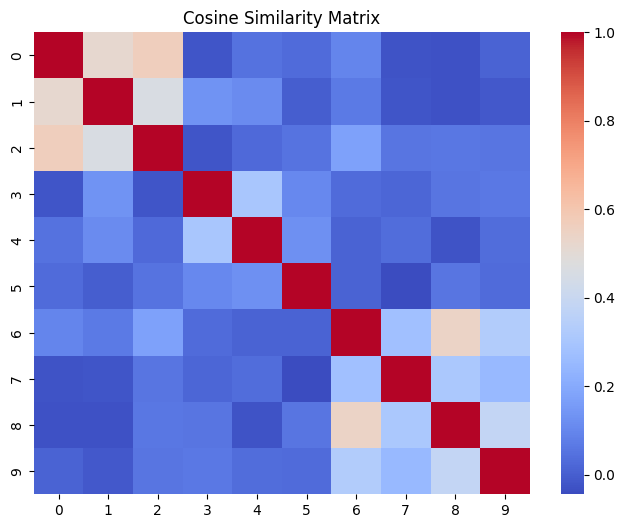

Top 2 similar sentences:
The bowler took a wicket with a yorker -> 0.748679
The batsman scored a century in the match -> 0.56821966


In [1]:
# Install library
!pip install sentence-transformers matplotlib seaborn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# 10 sentences (3 topics)
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took a wicket with a yorker",
    "The team won the cricket match easily",

    # Cooking
    "I cooked delicious pasta for dinner",
    "Boil the rice and add spices properly",
    "Baking a cake requires patience",

    # Cybersecurity
    "Cyber attacks can steal sensitive data",
    "Use strong passwords to protect accounts",
    "Encryption helps secure information",

    # Extra
    "Firewalls help in network security"
]

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(sentences)

# Cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=False, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

# Query
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Top 2 similar
top_indices = similarities.argsort()[-2:][::-1]

print("Top 2 similar sentences:")
for i in top_indices:
    print(sentences[i], "->", similarities[i])